# Data Catalog QA Notebook (clean)

Goal: for each catalog row, fetch a **real payload** (API response, file bytes, or asset) using a **small subset** and record PASS/FAIL/MANUAL.

Notes:
- Some sources are **assets** (PNG/MP4/PDF). That is still “real data” for those products.
- Some sources require **EarthScope auth** (Bearer token). Keep tokens local; do not commit them.


In [ ]:
# Keys are stored in keys.py (next to this notebook)
from keys import EARTHSCOPE_TOKEN, OPENTOPO_API_KEY

CATALOG_CSV = "data_catalog_v1.1.csv"  # file next to notebook

In [2]:
# If you don't already have these, uncomment:
# %pip -q install requests pandas

import os, re, json, time
from dataclasses import dataclass, asdict
from typing import Callable, Optional, Any, List, Tuple, Dict

import pandas as pd
import requests


In [3]:
df = pd.read_csv(CATALOG_CSV)
df.shape, df.columns.tolist()


((35, 12),
 ['Name',
  'Source',
  'Source_Link',
  'License',
  'refresh_cadence',
  'access_status',
  'feasibility_score',
  'estimated_cost',
  'note',
  'coverage_geo',
  'data_category',
  'blocking_issue'])

In [4]:
df[["Name","Source_Link"]].head(20)


,Name,Source_Link
0,NSF SAGE Facility IRISWS fedcatalog Web Service,https://service.iris.edu/irisws/fedcatalog/1/
1,GPS/GNSS Data,https://www.unavco.org/data/gps-gnss/gps-gnss....
2,Data Services Products: The Ground Motion Visu...,https://ds.iris.edu/ds/products/gmv/
3,Data Services Products: Event Plots,https://ds.iris.edu/ds/products/eventplots/
4,Data Services Products: Aftershocks,https://ds.iris.edu/ds/products/aftershocks/
5,Data Services Products: Exotic Seismic Events ...,https://ds.iris.edu/ds/products/esec/
6,Data Services Products: Global Empirical Green...,https://ds.iris.edu/ds/products/globalempirica...
7,Data Services Products: Moment Tensor Centroid,https://ds.iris.edu/ds/products/momenttensor/
8,Data Services Products: Source Time Function S...,https://ds.iris.edu/ds/products/sourcetimefunc...
9,Data Services Products: Continuous envelope fu...,https://ds.iris.edu/ds/products/envelopefuncti...


In [5]:
@dataclass
class QAResult:
    name: str
    url: str
    qa_class: str            # API_JSON | FILE_AUTH | ASSET_SPUD | HTML_TABLE | PORTAL_ONLY | MANUAL_AUTH
    status: str              # PASS | FAIL | MANUAL
    detail: str
    http_status: Optional[int] = None
    content_type: Optional[str] = None
    bytes_read: Optional[int] = None
    sample_preview: Optional[str] = None   # short text preview
    display_bytes: Optional[bytes] = None  # raw bytes for inline image display
    display_data: Optional[List[Dict]] = None  # structured rows for tabular display

def fetch_bytes(url: str, headers: Optional[dict]=None, max_bytes: int=200_000, timeout: int=30) -> dict:
    h = {"User-Agent":"data-catalog-qa/1.0"}
    if headers:
        h.update(headers)
    r = requests.get(url, headers=h, stream=True, allow_redirects=True, timeout=timeout)
    r.raise_for_status()
    ct = r.headers.get("content-type","")
    data = b""
    for chunk in r.iter_content(32_768):
        if not chunk:
            break
        data += chunk
        if len(data) >= max_bytes:
            break
    return {"final_url": r.url, "content_type": ct, "bytes": len(data), "sample": data, "status": r.status_code}

def safe_head_or_get(url: str, timeout: int=20, max_bytes: int=200_000) -> tuple[int,str,int]:
    try:
        r = requests.head(url, allow_redirects=True, timeout=timeout, headers={"User-Agent":"data-catalog-qa/1.0"})
        ct = r.headers.get("content-type","")
        if r.status_code in (405,403) or not ct:
            raise RuntimeError("HEAD not usable; fallback to GET")
        return r.status_code, ct, 0
    except Exception:
        j = fetch_bytes(url, max_bytes=max_bytes, timeout=timeout)
        return j["status"], j["content_type"], j["bytes"]

def earthscope_headers() -> dict:
    return {"Authorization": f"Bearer {EARTHSCOPE_TOKEN}"} if EARTHSCOPE_TOKEN else {}

def is_binary_content_type(ct: str) -> bool:
    c = (ct or "").lower()
    return any(x in c for x in ["image/", "video/", "application/pdf", "application/zip", "application/octet-stream"])

def text_preview(b: bytes, limit: int=200) -> str:
    try:
        t = b.decode("utf-8", errors="replace")
    except Exception:
        return ""
    t = t.replace("\r","").replace("\t"," ")
    return t[:limit]


## IRISWS Fedcatalog (JSON)

In [6]:
def qa_fedcatalog(row: pd.Series) -> QAResult:
    base = str(row["Source_Link"]).rstrip("/")
    url = f"{base}/datacenters?format=JSON"
    try:
        obj = requests.get(url, timeout=30, headers={"User-Agent":"data-catalog-qa/1.0"}).json()
        ok = isinstance(obj, list) and len(obj) > 0
        rows = [{"name": d.get("name",""), "description": d.get("description",""), "website": d.get("website","")} for d in obj[:5]]
        return QAResult(
            name=row["Name"], url=url, qa_class="API_JSON",
            status="PASS" if ok else "FAIL",
            detail="Fedcatalog datacenters JSON" if ok else f"Unexpected JSON shape: {type(obj)}",
            http_status=200, content_type="application/json",
            sample_preview=str(obj[0])[:200] if ok else None,
            display_data=rows if ok else None,
        )
    except Exception as e:
        return QAResult(row["Name"], url, "API_JSON", "FAIL", str(e))


## SPUD products (real payload assets)

In [7]:
def spud_ids(product_type: str, limit: int=3) -> List[str]:
    url = f"https://ds.iris.edu/spudservice/{product_type}/ids"
    r = requests.get(url, params={"maxitems": limit, "order":"desc"}, timeout=30, headers={"User-Agent":"data-catalog-qa/1.0"})
    r.raise_for_status()
    return [ln.strip().split()[0] for ln in r.text.splitlines() if ln.strip()][:limit]

def spud_payload_link(product_type: str, spud_id: str) -> Optional[str]:
    import xml.etree.ElementTree as ET
    url = f"https://ds.iris.edu/spudservice/{product_type}/{spud_id}"
    r = requests.get(url, timeout=30, headers={"User-Agent":"data-catalog-qa/1.0"})
    r.raise_for_status()
    root = ET.fromstring(r.text)
    for el in root.iter():
        href = el.attrib.get("href")
        if href and "spudservice/data/" in href:
            return href
        if el.text and "spudservice/data/" in el.text:
            return el.text.strip()
    return None

# Max bytes to store for inline image display (500 KB)
_IMAGE_DISPLAY_LIMIT = 500_000

def qa_spud_asset(row: pd.Series, product_type: str) -> QAResult:
    try:
        ids = spud_ids(product_type, limit=3)
        if not ids:
            return QAResult(row["Name"], row["Source_Link"], "ASSET_SPUD", "FAIL", f"No SPUD ids for {product_type}")
        link = spud_payload_link(product_type, ids[0])
        if not link:
            return QAResult(row["Name"], row["Source_Link"], "ASSET_SPUD", "FAIL", f"No payload link for {product_type} id={ids[0]}")
        payload = fetch_bytes(link, max_bytes=_IMAGE_DISPLAY_LIMIT)
        ct = payload["content_type"]
        is_img = "image/" in (ct or "").lower()
        raw = payload["sample"] if is_img else None
        return QAResult(
            name=row["Name"], url=row["Source_Link"], qa_class="ASSET_SPUD",
            status="PASS",
            detail=f"SPUD {product_type}: sample_id={ids[0]}",
            http_status=payload["status"], content_type=ct,
            bytes_read=payload["bytes"],
            sample_preview=None if is_binary_content_type(ct) else text_preview(payload["sample"]),
            display_bytes=raw,
        )
    except requests.exceptions.HTTPError as e:
        if e.response is not None and e.response.status_code == 404:
            # SPUD endpoint retired — fall back to landing-page probe
            code, ct, nb = safe_head_or_get(str(row["Source_Link"]))
            return QAResult(
                row["Name"], row["Source_Link"], "PORTAL_ONLY",
                "PASS" if 200 <= code < 400 else "FAIL",
                f"SPUD /{product_type}/ids returned 404 (product retired). Landing page probe.",
                http_status=code, content_type=ct, bytes_read=nb,
            )
        return QAResult(row["Name"], row["Source_Link"], "ASSET_SPUD", "FAIL", str(e))
    except Exception as e:
        return QAResult(row["Name"], row["Source_Link"], "ASSET_SPUD", "FAIL", str(e))

# Active SPUD product type slugs (verified working).
# esec / envelopefunction / globalempiricalgreens removed — /ids returns 404.
SPUD_PRODUCT_MAP: List[Tuple[re.Pattern, str]] = [
    (re.compile(r"/ds/products/eventplots/?$"),   "eventplot"),
    (re.compile(r"/ds/products/aftershocks/?$"),  "aftershock"),
    (re.compile(r"/ds/products/momenttensor/?$"), "momenttensor"),
    (re.compile(r"/spud/momenttensor"),           "momenttensor"),   # query-page URL
    (re.compile(r"/ds/products/gmv/?$"),          "gmv"),
    (re.compile(r"/ds/products/sourcetimefunc"),  "sourcetimefunction"),
    (re.compile(r"/ds/products/eqenergy/?$"),     "eqenergy"),
]

def spud_type_from_url(url: str) -> Optional[str]:
    for pat, ptype in SPUD_PRODUCT_MAP:
        if pat.search(url):
            return ptype
    return None

## EarthScope/GAGE file server (auth-required real file bytes)

In [8]:
# Maps a URL keyword → EarthScope GAGE archive subdirectory.
# These are tried in order; first match wins.
_EARTHSCOPE_ARCHIVE_ROUTES: List[Tuple[str, str]] = [
    ("gps-gnss",              "gnss/rinex/obs/2023/001/"),
    ("strain-seismic/creep",  "strain/creep/"),
    ("strain-seismic/tilt",   "strain/tilt/"),
    ("strain-seismic/pore",   "strain/pore/"),
    ("strain-seismic/seismic","strain/seismic/"),
    ("strain-seismic/bsm",    "strain/bsm/"),
    ("strain-seismic",        "strain/bsm/"),          # generic strain fallback
    ("unavco.org",            "gnss/rinex/obs/2023/001/"),  # UNAVCO catch-all
]

# When the top-level subdir returns an HTML redirect (JavaScript redirect page),
# try a known station subdirectory one level deeper.
_STATION_FALLBACK: Dict[str, str] = {
    "strain/creep/":    "B084/",
    "strain/tilt/":     "B001/",
    "strain/pore/":     "B001/",
    "strain/seismic/":  "B084/",
    "strain/bsm/":      "B001/",
}

_ES_ROOT = "https://gage-data.earthscope.org/archive/"

def _earthscope_archive_subdir(source_url: str) -> str:
    for keyword, subdir in _EARTHSCOPE_ARCHIVE_ROUTES:
        if keyword in source_url:
            return subdir
    return "gnss/rinex/obs/2023/001/"

def _is_html_response(data: bytes) -> bool:
    """Return True if the bytes look like an HTML page rather than a file listing."""
    snippet = data[:500].lower()
    return any(tok in snippet for tok in (b"<html", b"<!doctype", b"window.location", b"<head"))

def qa_earthscope_file_sample(row: pd.Series) -> QAResult:
    if not EARTHSCOPE_TOKEN:
        return QAResult(row["Name"], row["Source_Link"], "FILE_AUTH", "MANUAL", "Missing EARTHSCOPE_TOKEN")

    subdir = _earthscope_archive_subdir(str(row["Source_Link"]))
    list_url = f"{_ES_ROOT}{subdir}?list"
    try:
        listing = fetch_bytes(list_url, headers=earthscope_headers(), max_bytes=50_000)
        raw = listing["sample"]

        # If we got an HTML redirect page, try one known station subdirectory deeper
        if _is_html_response(raw):
            station_sub = _STATION_FALLBACK.get(subdir)
            if station_sub:
                subdir    = subdir + station_sub
                list_url  = f"{_ES_ROOT}{subdir}?list"
                listing   = fetch_bytes(list_url, headers=earthscope_headers(), max_bytes=50_000)
                raw       = listing["sample"]

        lines = raw.decode("utf-8", "replace").splitlines()
        filenames = [ln.split()[0] for ln in lines if ln.strip() and not _is_html_response(ln.encode())]

        # Filter obvious HTML lines
        filenames = [f for f in filenames if not f.startswith("<")]

        if not filenames:
            # Last resort: fall back to GNSS RINEX
            subdir    = "gnss/rinex/obs/2023/001/"
            list_url  = f"{_ES_ROOT}{subdir}?list"
            listing   = fetch_bytes(list_url, headers=earthscope_headers(), max_bytes=50_000)
            lines     = listing["sample"].decode("utf-8", "replace").splitlines()
            filenames = [ln.split()[0] for ln in lines if ln.strip() and not ln.startswith("<")]

        if not filenames:
            return QAResult(row["Name"], row["Source_Link"], "FILE_AUTH", "FAIL",
                            f"Empty listing at {list_url}")

        file_url = f"{_ES_ROOT}{subdir}{filenames[0]}"
        payload  = fetch_bytes(file_url, headers=earthscope_headers(), max_bytes=200_000)
        return QAResult(
            name=row["Name"], url=row["Source_Link"], qa_class="FILE_AUTH",
            status="PASS",
            detail=f"EarthScope archive OK | subdir={subdir} | file={filenames[0]}",
            http_status=payload["status"], content_type=payload["content_type"],
            bytes_read=payload["bytes"],
            sample_preview=None if is_binary_content_type(payload["content_type"])
                           else text_preview(payload["sample"]),
        )
    except Exception as e:
        return QAResult(row["Name"], row["Source_Link"], "FILE_AUTH", "FAIL", str(e))

## USGS (real GeoJSON rows)

In [9]:
def qa_usgs_catalog(_row: pd.Series) -> QAResult:
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&limit=5&orderby=time"
    try:
        payload = fetch_bytes(url, max_bytes=200_000)
        obj = json.loads(payload["sample"].decode("utf-8","replace"))
        feats = obj.get("features", [])[:5]
        rows = []
        for f in feats:
            p = f.get("properties") or {}
            rows.append({"id": f.get("id"), "mag": p.get("mag"), "place": p.get("place"),
                         "time_utc": pd.to_datetime(p.get("time"), unit="ms", utc=True) if p.get("time") else None,
                         "type": p.get("type")})
        return QAResult(
            name=_row["Name"], url=_row["Source_Link"], qa_class="API_JSON",
            status="PASS", detail="USGS GeoJSON sample (5 events)",
            http_status=payload["status"], content_type=payload["content_type"],
            bytes_read=payload["bytes"],
            sample_preview=str(rows[:2])[:200],
            display_data=rows,
        )
    except Exception as e:
        return QAResult(_row["Name"], _row["Source_Link"], "API_JSON", "FAIL", str(e))


## OpenTopography (API key → file payload)

In [10]:
def qa_opentopo(_row: pd.Series) -> QAResult:
    if not OPENTOPO_API_KEY:
        return QAResult(_row["Name"], _row["Source_Link"], "FILE_AUTH", "MANUAL", "Missing OPENTOPO_API_KEY")

    url = (
        "https://portal.opentopography.org/API/globaldem"
        "?demtype=SRTMGL1&south=34&north=34.01&west=-119&east=-118.99"
        f"&outputFormat=GTiff&API_Key={OPENTOPO_API_KEY}"
    )
    try:
        payload = fetch_bytes(url, max_bytes=200_000)
        return QAResult(
            name=_row["Name"], url=_row["Source_Link"], qa_class="FILE_AUTH",
            status="PASS", detail="OpenTopography SRTMGL1 GeoTIFF sample (tiny bbox)",
            http_status=payload["status"], content_type=payload["content_type"],
            bytes_read=payload["bytes"],
        )
    except Exception as e:
        return QAResult(_row["Name"], _row["Source_Link"], "FILE_AUTH", "FAIL", str(e))


## SSN (Servicio Sismológico Nacional) — real event data

In [11]:
def qa_ssn_catalog(_row: pd.Series) -> QAResult:
    """
    The SSN catalog app at http://www2.ssn.unam.mx:8080/catalogo/ is a Java web app.
    It exposes a CSV/JSON download endpoint we can query for recent events.
    Pattern discovered from the form action: /catalogo/reportecsv (POST → CSV).
    We try that; if it fails we fall back to a HEAD probe.
    """
    base = "http://www2.ssn.unam.mx:8080"
    # Try the CSV endpoint with a small date window
    import datetime as dt
    today = dt.date.today()
    start = (today - dt.timedelta(days=30)).strftime("%Y-%m-%d")
    end   = today.strftime("%Y-%m-%d")

    # Known working CSV download URL for SSN catalog
    csv_url = f"{base}/catalogo/reportecsv?inicio={start}&fin={end}"
    try:
        r = requests.get(csv_url, timeout=30, headers={"User-Agent":"data-catalog-qa/1.0"}, allow_redirects=True)
        if r.status_code == 200 and ("text/csv" in r.headers.get("content-type","") or r.text.strip().startswith(("Fecha","fecha","#"))):
            lines = [ln for ln in r.text.splitlines() if ln.strip()]
            header = lines[0].split(",") if lines else []
            rows = []
            for ln in lines[1:6]:
                parts = ln.split(",")
                rows.append(dict(zip(header, parts)))
            return QAResult(
                name=_row["Name"], url=_row["Source_Link"], qa_class="API_CSV",
                status="PASS", detail=f"SSN CSV {len(lines)-1} events ({start} to {end})",
                http_status=r.status_code, content_type=r.headers.get("content-type",""),
                bytes_read=len(r.content),
                sample_preview=r.text[:200],
                display_data=rows if rows else None,
            )
        # Fallback: plain reachability
        code, ct, nb = safe_head_or_get(str(_row["Source_Link"]))
        return QAResult(_row["Name"], _row["Source_Link"], "PORTAL_ONLY",
                        "PASS" if 200 <= code < 400 else "FAIL",
                        "SSN landing page (CSV endpoint returned non-CSV response)",
                        http_status=code, content_type=ct, bytes_read=nb)
    except Exception as e:
        return QAResult(_row["Name"], _row["Source_Link"], "API_CSV", "FAIL", str(e))


## iTrend Dataverse — structured dataset listing

In [12]:
def qa_itrend_dataverse(_row: pd.Series) -> QAResult:
    """
    Uses the Dataverse native REST API to list datasets in the 'sismos' collection.
    Endpoint: /api/search?q=*&subtree=sismos&type=dataset&per_page=5
    """
    base = "https://datospararesiliencia.cl"
    search_url = f"{base}/api/search?q=*&subtree=sismos&type=dataset&per_page=5"
    try:
        r = requests.get(search_url, timeout=30, headers={"User-Agent":"data-catalog-qa/1.0"}, allow_redirects=True)
        r.raise_for_status()
        obj = r.json()
        items = obj.get("data", {}).get("items", [])
        rows = [{"name": it.get("name",""), "global_id": it.get("global_id",""),
                 "published_at": it.get("published_at",""), "type": it.get("type","")}
                for it in items[:5]]
        ok = len(rows) > 0
        return QAResult(
            name=_row["Name"], url=_row["Source_Link"], qa_class="API_JSON",
            status="PASS" if ok else "FAIL",
            detail=f"Dataverse search: {len(items)} dataset(s) in 'sismos'",
            http_status=r.status_code, content_type=r.headers.get("content-type",""),
            bytes_read=len(r.content),
            sample_preview=str(rows[:2])[:200],
            display_data=rows if ok else None,
        )
    except Exception as e:
        return QAResult(_row["Name"], _row["Source_Link"], "API_JSON", "FAIL", str(e))


## Router + runner

In [13]:
def basic_portal_probe(row: pd.Series) -> QAResult:
    code, ct, n = safe_head_or_get(str(row["Source_Link"]))
    status = "PASS" if 200 <= code < 400 else "FAIL"
    return QAResult(row["Name"], row["Source_Link"], "PORTAL_ONLY", status,
                    "Reachable landing page (no direct payload mapped).",
                    http_status=code, content_type=ct, bytes_read=n)

def pick_tester(row: pd.Series) -> Callable[[pd.Series], QAResult]:
    url = str(row["Source_Link"])

    # ── Fedcatalog ────────────────────────────────────────────────────────────
    if "service.iris.edu/irisws/fedcatalog" in url:
        return qa_fedcatalog

    # ── SPUD product pages (check before generic ds.iris.edu catch) ───────────
    ptype = spud_type_from_url(url)
    if ptype:
        return lambda r, p=ptype: qa_spud_asset(r, p)

    # ── USGS earthquake API ───────────────────────────────────────────────────
    # /browse/ URLs are curated HTML lists, not live API feeds → portal probe
    if "earthquake.usgs.gov/earthquakes" in url:
        if "/browse/" in url:
            return basic_portal_probe
        return qa_usgs_catalog

    # ── OpenTopography portal → API payload ───────────────────────────────────
    if "portal.opentopography.org" in url:
        return qa_opentopo

    # ── LiDAR/SfM — data lives on OpenTopography, not EarthScope archive ──────
    if "lidar-sfm" in url:
        return qa_opentopo

    # ── GNSS Realtime — NTRIP streaming protocol, not file-listable ───────────
    if "gnss-realtime" in url or "gnss/realtime" in url:
        return basic_portal_probe

    # ── Seafloor geodesy — no archive path on GAGE file server ────────────────
    if "seafloor" in url:
        return basic_portal_probe

    # ── EarthScope / UNAVCO portals → authenticated file server ──────────────
    if any(kw in url for kw in ("unavco.org", "earthscope.org/data/gnss", "strain-seismic")):
        return qa_earthscope_file_sample

    # ── SSN catalog ───────────────────────────────────────────────────────────
    if "ssn.unam.mx" in url and "catalogo" in url:
        return qa_ssn_catalog

    # ── iTrend Dataverse ──────────────────────────────────────────────────────
    if "datospararesiliencia.cl" in url:
        return qa_itrend_dataverse

    # Default: reachability probe
    return basic_portal_probe


# Global list of raw QAResult objects (populated by run_qa; used by display cell)
qa_results: List[QAResult] = []

def run_qa() -> pd.DataFrame:
    global qa_results
    qa_results = []
    out = []
    for _, row in df.iterrows():
        fn = pick_tester(row)
        res = fn(row)
        qa_results.append(res)
        # Build DataFrame row, excluding non-serialisable display fields
        d = {k: v for k, v in vars(res).items() if k not in ("display_bytes", "display_data")}
        out.append(d)
        time.sleep(0.2)
    return pd.DataFrame(out)

results = run_qa()
results

,name,url,qa_class,status,detail,http_status,content_type,bytes_read,sample_preview
0,NSF SAGE Facility IRISWS fedcatalog Web Service,https://service.iris.edu/irisws/fedcatalog/1/d...,API_JSON,PASS,Fedcatalog datacenters JSON,200.0,application/json,NaN,"{'name': 'RESIF', 'description': 'RESIF', 'web..."
1,GPS/GNSS Data,https://www.unavco.org/data/gps-gnss/gps-gnss....,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
2,Data Services Products: The Ground Motion Visu...,https://ds.iris.edu/ds/products/gmv/,ASSET_SPUD,PASS,SPUD gmv: sample_id=1841,200.0,video/mp4,524288.0,None
3,Data Services Products: Event Plots,https://ds.iris.edu/ds/products/eventplots/,ASSET_SPUD,PASS,SPUD eventplot: sample_id=3229,200.0,image/png,391555.0,None
4,Data Services Products: Aftershocks,https://ds.iris.edu/ds/products/aftershocks/,ASSET_SPUD,PASS,SPUD aftershock: sample_id=9753303,200.0,image/png,420430.0,None
5,Data Services Products: Exotic Seismic Events ...,https://ds.iris.edu/ds/products/esec/,PORTAL_ONLY,PASS,Reachable landing page (no direct payload mapp...,200.0,text/html; charset=utf-8,0.0,None
6,Data Services Products: Global Empirical Green...,https://ds.iris.edu/ds/products/globalempirica...,PORTAL_ONLY,PASS,Reachable landing page (no direct payload mapp...,200.0,text/html; charset=utf-8,0.0,None
7,Data Services Products: Moment Tensor Centroid,https://ds.iris.edu/ds/products/momenttensor/,ASSET_SPUD,PASS,SPUD momenttensor: sample_id=72388,200.0,image/png,754.0,None
8,Data Services Products: Source Time Function S...,https://ds.iris.edu/ds/products/sourcetimefunc...,ASSET_SPUD,PASS,SPUD sourcetimefunction: sample_id=1756773,200.0,image/png,42904.0,None
9,Data Services Products: Continuous envelope fu...,https://ds.iris.edu/ds/products/envelopefuncti...,PORTAL_ONLY,PASS,Reachable landing page (no direct payload mapp...,200.0,text/html; charset=utf-8,0.0,None


In [14]:
results.groupby(["qa_class","status"]).size().sort_values(ascending=False)


qa_class     status
PORTAL_ONLY  PASS      16
ASSET_SPUD   PASS       7
FILE_AUTH    FAIL       7
API_JSON     PASS       3
FILE_AUTH    PASS       2
dtype: int64

In [15]:
# show non-PASS first
results.sort_values(["status","qa_class","name"]).head(50)


,name,url,qa_class,status,detail,http_status,content_type,bytes_read,sample_preview
16,Borehole Pore Pressure Data,https://www.unavco.org/data/strain-seismic/por...,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
17,Borehole Seismic Data,https://www.unavco.org/data/strain-seismic/sei...,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
18,Borehole Strainmeter Data,https://www.unavco.org/data/strain-seismic/bsm...,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
15,Borehole Tilt Data,https://www.unavco.org/data/strain-seismic/til...,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
14,Creepmeter Data,https://www.unavco.org/data/strain-seismic/cre...,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
1,GPS/GNSS Data,https://www.unavco.org/data/gps-gnss/gps-gnss....,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
12,GPS/GNSS Data,https://www.unavco.org/data/gps-gnss/gps-gnss....,FILE_AUTH,FAIL,404 Client Error: Not Found for url: https://g...,NaN,None,NaN,None
29,Earthquake Hazards Program: Earthquake Catalog,https://earthquake.usgs.gov/earthquakes/search/,API_JSON,PASS,USGS GeoJSON sample (5 events),200.0,application/json; charset=utf-8,3896.0,"[{'id': 'aka2026doemqk', 'mag': 1, 'place': '3..."
0,NSF SAGE Facility IRISWS fedcatalog Web Service,https://service.iris.edu/irisws/fedcatalog/1/d...,API_JSON,PASS,Fedcatalog datacenters JSON,200.0,application/json,NaN,"{'name': 'RESIF', 'description': 'RESIF', 'web..."
34,iTrend Data Platform,https://datospararesiliencia.cl/dataverse/sismos,API_JSON,PASS,Dataverse search: 5 dataset(s) in 'sismos',200.0,application/json;charset=UTF-8,10235.0,[{'name': 'Registros de aceleración (no correg...


## Data proof — per-dataset payload preview

,name,description,website
0,RESIF,RESIF,http://www.resif.fr
1,IPGP,IPGP Data Center,http://datacenter.ipgp.fr
2,LMU,LMU Munich,http://www.geophysik.uni-muenchen.de/observato...
3,NIEP,National Institute for Earth Physics,http://www.orfeus-eu.org/eida/eida_niep.html
4,IRISDMC,EarthScope Data Center,https://www.earthscope.org/data/


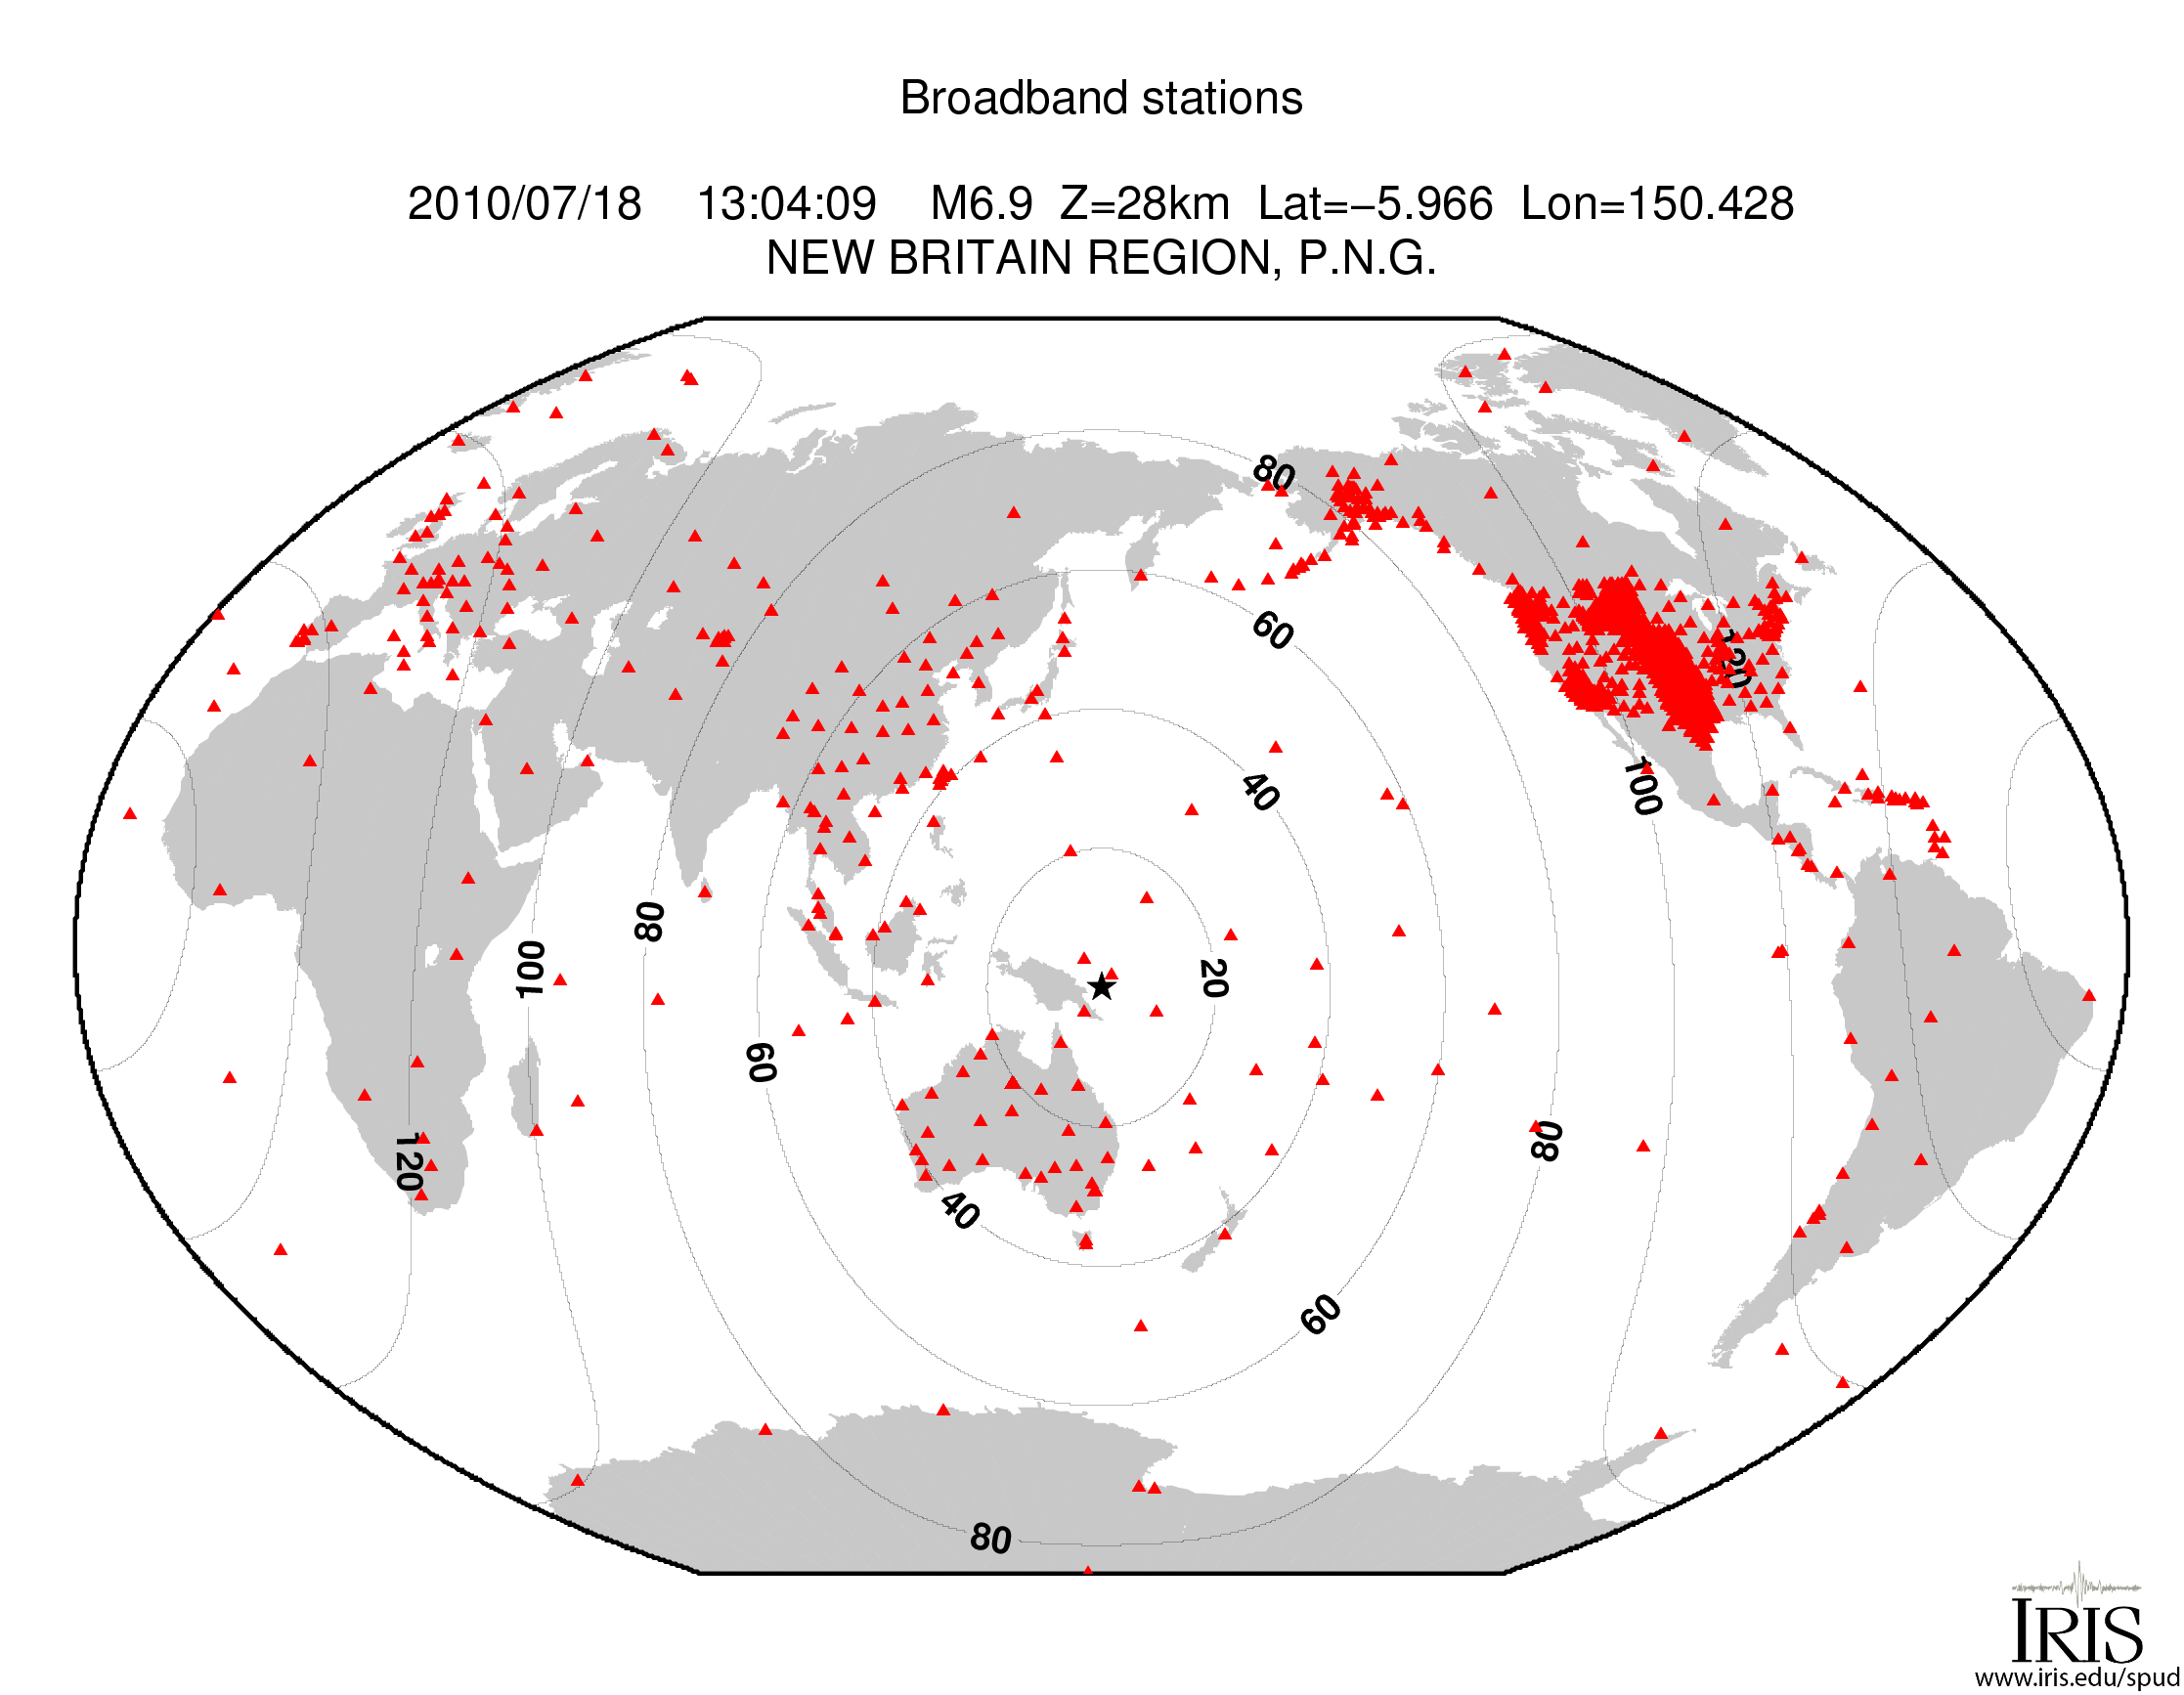

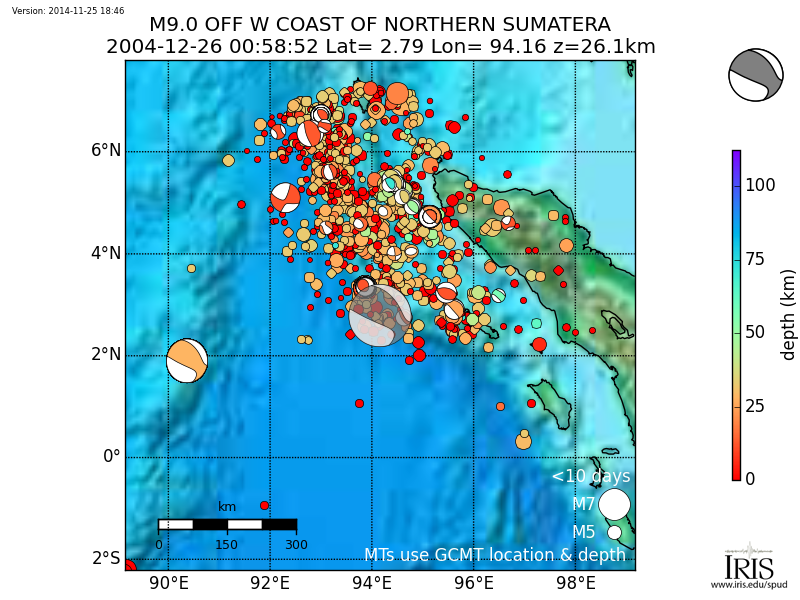

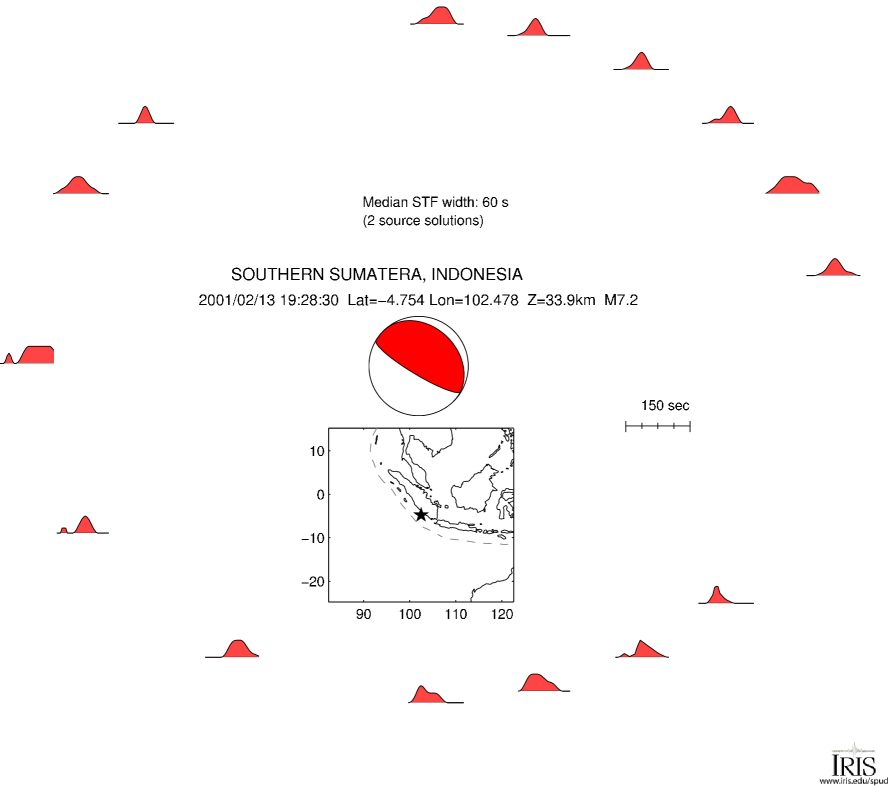

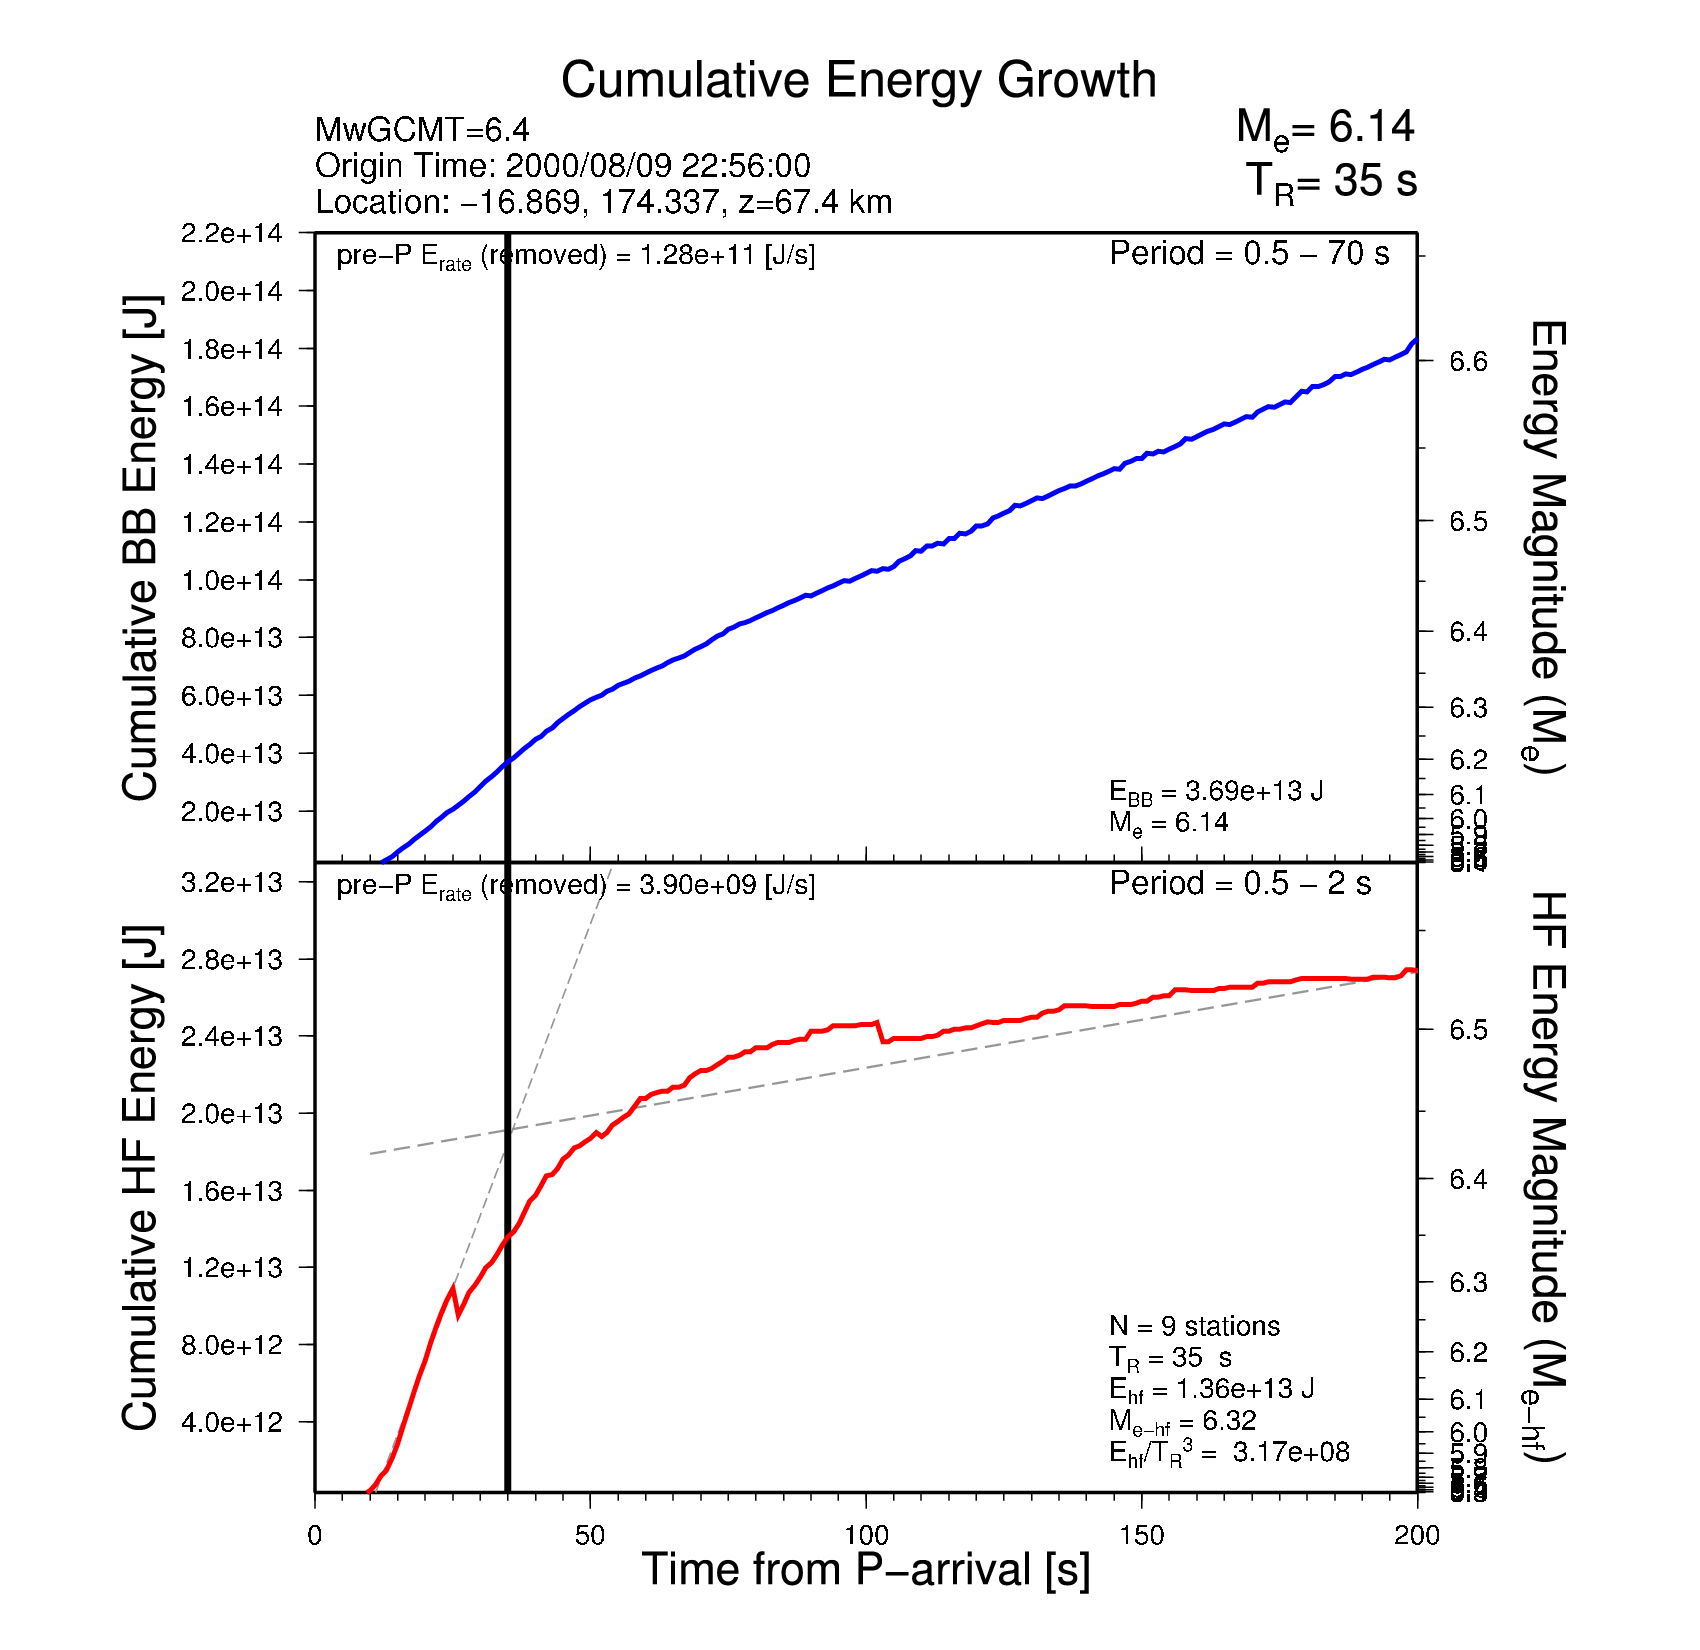

,id,mag,place,time_utc,type
0,aka2026doemqk,1.00,"33 km SE of Minto, Alaska",2026-02-20 05:07:05.449000+00:00,earthquake
1,tx2026dodzej,1.40,"62 km S of Whites City, New Mexico",2026-02-20 04:51:36.836000+00:00,earthquake
2,aka2026dodyps,2.10,"49 km WSW of Cantwell, Alaska",2026-02-20 04:50:48.904000+00:00,earthquake
3,hv74903531,2.17,"8 km NNE of Pāhala, Hawaii",2026-02-20 04:38:35.110000+00:00,earthquake
4,aka2026dodfmh,1.40,"13 km N of Meadow Lakes, Alaska",2026-02-20 04:28:38.359000+00:00,earthquake


,name,global_id,published_at,type
0,Registros de aceleración (no corregidos) desde...,doi:10.71578/DWVOZZ,2024-12-16T12:13:49Z,dataset
1,Registros de aceleración (no corregidos) entre...,doi:10.71578/ICGS41,2024-11-19T18:22:33Z,dataset
2,Catastro de viviendas para el terremoto de Ill...,doi:10.71578/JT39W3,2024-10-07T16:04:39Z,dataset
3,Parámetros de Gutenberg-Richter por Leyton et ...,doi:10.71578/LKDM1D,2024-10-08T16:21:50Z,dataset
4,Centroides de tensores de momento sísmico glob...,doi:10.71578/QSTNPJ,2024-10-07T14:10:50Z,dataset


In [16]:
from IPython.display import display as ipy_display, Image as IPyImage, HTML
import html as _html

# Status badge colours
_BADGE = {"PASS": "#2ecc71", "FAIL": "#e74c3c", "MANUAL": "#f39c12"}

def _header_html(res: QAResult) -> str:
    color = _BADGE.get(res.status, "#95a5a6")
    badge = (f'<span style="background:{color};color:white;padding:2px 8px;'
             f'border-radius:4px;font-weight:bold;font-size:0.85em">{res.status}</span>')
    cls   = (f'<span style="color:#888;font-size:0.8em">[{_html.escape(res.qa_class)}]</span>')
    name  = f'<strong>{_html.escape(res.name)}</strong>'
    url   = (f'<a href="{_html.escape(res.url)}" target="_blank" '
             f'style="font-size:0.78em;color:#3498db">{_html.escape(res.url[:80])}…</a>'
             if len(res.url) > 80 else
             f'<a href="{_html.escape(res.url)}" target="_blank" '
             f'style="font-size:0.78em;color:#3498db">{_html.escape(res.url)}</a>')
    return f'<div style="margin:8px 0 2px 0">{badge} {cls} {name}<br/>{url}</div>'

for res in qa_results:
    ipy_display(HTML(_header_html(res)))

    ct = (res.content_type or "").lower()

    # ── 1. Inline image ──────────────────────────────────────────────────
    if res.display_bytes and "image/" in ct:
        ipy_display(IPyImage(data=res.display_bytes, width=480))

    # ── 2. Tabular / structured data ─────────────────────────────────────
    elif res.display_data:
        df_show = pd.DataFrame(res.display_data).head(5)
        ipy_display(df_show)

    # ── 3. Binary file confirmed (non-image, non-tabular) ────────────────
    elif res.bytes_read and res.bytes_read > 0 and is_binary_content_type(ct):
        size_kb = res.bytes_read / 1024
        ipy_display(HTML(
            f'<p style="color:#555;font-family:monospace">✓ Binary payload received: '
            f'<strong>{_html.escape(ct)}</strong> &nbsp;|&nbsp; '
            f'<strong>{size_kb:.1f} KB</strong> &nbsp;|&nbsp; {_html.escape(res.detail)}</p>'
        ))

    # ── 4. Text preview (non-binary) ─────────────────────────────────────
    elif res.sample_preview:
        escaped = _html.escape(res.sample_preview[:300])
        ipy_display(HTML(
            f'<pre style="background:#f8f8f8;padding:6px;font-size:0.8em;'
            f'border-left:3px solid #ccc;overflow:auto">{escaped}</pre>'
        ))

    # ── 5. PORTAL_ONLY / MANUAL — show detail text ───────────────────────
    else:
        detail_txt = _html.escape(res.detail or "no detail")
        http_txt   = f" (HTTP {res.http_status})" if res.http_status else ""
        ipy_display(HTML(
            f'<p style="color:#666;font-size:0.85em">ℹ {detail_txt}{http_txt}</p>'
        ))
